In [1]:
CREMAD = "/kaggle/input/cremad/AudioWAV/"
RAVDESS = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
SAVEE = "/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/"
TESS = "/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/"
MLEND = "/kaggle/input/mlend-spoken-numerals/MLEndSND_Public/MLEndSND_Public/"

In [2]:
import os
import math, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
audios = pd.DataFrame(data=[], columns=['Dataset', 'Path', "Emotion"])
audios

,Dataset,Path,Emotion


In [5]:
# Adding CREMA-D files to the dataframe
emotion_map = {"DIS": "Disgust", "SAD": "Sad", "HAP": "Happy", 
              "NEU": "Neutral", "FEA": "Fearful", "ANG": "Angry"}

for file in os.listdir(CREMAD):
    emotion = emotion_map[file.split("_")[2]]
    
    audios.loc[len(audios)] = {"Dataset": "CREMA-D", "Path": CREMAD+file, "Emotion": emotion}

In [6]:
# 01 = neutral, 02 = calm, 03 = happy, 04 = sad, 05 = angry, 06 = fearful, 07 = disgust, 08 = surprised
emotion_map = {1: "Neutral", 2: "Calm", 3: "Happy", 4: "Sad", 5: "Angry", 6: "Fearful", 7: "Disgust", 8: "Surprised"}

for folder in os.listdir(RAVDESS):
    for file in os.listdir(RAVDESS+folder):
        emotion = emotion_map[int(file.split("-")[2])]

        audios.loc[len(audios)] = {"Dataset": "RAVDESS", "Path": RAVDESS+folder+"/"+file, "Emotion": emotion}

In [7]:
audios.Emotion.unique(), audios.Emotion.unique().size

(array(['Disgust', 'Happy', 'Sad', 'Neutral', 'Fearful', 'Angry',
        'Surprised', 'Calm'], dtype=object),
 8)

In [8]:
emotion_map = {'a': "Angry", 'd': "Disgust", 'f': "Fearful", 'h': "Happy", 
               'n': "Neutral", 'sa': "Sad", 'su': "Surprised"}

for file in os.listdir(SAVEE):
    emotion = emotion_map[file.split("_")[1].split(".")[0][:-2]]
    
    audios.loc[len(audios)] = {"Dataset": "SAVEE", "Path": SAVEE+file, "Emotion": emotion}

In [9]:
emotion_map = {"fear": "Fearful", "happy": "Happy", "disgust": "Disgust", "sad": "Sad",
               "ps": "Surprised", "angry": "Angry", 'neutral': "Neutral"}

for folder in os.listdir(TESS):
    for file in os.listdir(TESS+folder):
        emotion = emotion_map[file.split("_")[2].split(".")[0]]

        audios.loc[len(audios)] = {"Dataset": "TESS", "Path": TESS+folder+"/"+file, "Emotion": emotion}

In [10]:
df = pd.read_csv('/kaggle/input/mlend-spoken-numerals/MLEndSND_Speakers_Demographics.csv')
df.Nationality.value_counts()

Nationality
Indian           43
British          37
Chinese          18
Pakistani         5
Saudi Arabian     3
Hong Kong         3
Nigerian          3
Dutch             2
Portuguese        2
Greek             2
Bangladeshi       2
Polish            2
Egyptian          2
German            2
Filipino          1
Afghanistani      1
Spanish           1
Norwegian         1
Italian           1
Uruguayan         1
Iranian           1
Mexican           1
Syrian            1
Hungarian         1
Kazakhstan        1
Irish             1
Lithuanian        1
Romanian          1
Malaysian         1
Palestinian       1
Thai              1
Name: count, dtype: int64

In [11]:
nationalities = ["Indian", "Pakistani", "Bangladeshi", "British", "Afghanistani"]
spk_nums = df[df.Nationality.isin(nationalities)]['Speaker'].tolist()
spk_nums

[2,
 4,
 5,
 6,
 13,
 14,
 20,
 22,
 23,
 26,
 27,
 29,
 30,
 31,
 32,
 33,
 35,
 36,
 37,
 38,
 39,
 42,
 43,
 45,
 48,
 50,
 53,
 54,
 56,
 57,
 59,
 60,
 61,
 62,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 76,
 78,
 81,
 82,
 85,
 86,
 87,
 88,
 89,
 91,
 96,
 97,
 98,
 100,
 101,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 116,
 117,
 121,
 122,
 124,
 125,
 129,
 130,
 131,
 132,
 133,
 134,
 136,
 137,
 138,
 140,
 141,
 143,
 146,
 147,
 149,
 151]

In [12]:
attrs_df = pd.read_csv("/kaggle/input/mlend-spoken-numerals/MLEndSND_Audio_Attributes.csv")
attrs_df.head()

,Public filename,Numeral,Intonation,Speaker
0,0,3,excited,59
1,1,1000000,question,31
2,3,15,excited,107
3,4,13,excited,114
4,5,19,neutral,132


In [13]:
# Converting the filenames from integers to a 5-digit string
attrs_df['Public filename'] = attrs_df['Public filename'].astype(str).str.zfill(5)+".wav"
attrs_df.head()

,Public filename,Numeral,Intonation,Speaker
0,00000.wav,3,excited,59
1,00001.wav,1000000,question,31
2,00003.wav,15,excited,107
3,00004.wav,13,excited,114
4,00005.wav,19,neutral,132


In [14]:
# Filtering only the Indian speakers
filtered_df = attrs_df[attrs_df['Speaker'].isin(spk_nums)].reset_index()
filtered_df

,index,Public filename,Numeral,Intonation,Speaker
0,0,00000.wav,3,excited,59
1,1,00001.wav,1000000,question,31
2,2,00003.wav,15,excited,107
3,4,00005.wav,19,neutral,132
4,6,00008.wav,2,excited,38
...,...,...,...,...,...
18855,32647,47059.wav,14,bored,61
18856,32649,47063.wav,11,neutral,33
18857,32650,47064.wav,9,excited,91
18858,32651,47065.wav,1000000000,neutral,111


In [15]:
# Remapping the Intonations to Emotions
filtered_df["Emotion"] = filtered_df.Intonation.replace({"neutral": "Neutral", "bored": "Sad", "excited": "Happy", "question": "Calm"})
filtered_df['Dataset'] = "MLEnd"
filtered_df['Path'] = MLEND + filtered_df['Public filename']

# Adding the files to the main dataframe
audios = pd.concat([audios, filtered_df[['Dataset', "Path", "Emotion"]]], ignore_index=True)

In [16]:
audios.Emotion.unique()

array(['Disgust', 'Happy', 'Sad', 'Neutral', 'Fearful', 'Angry',
       'Surprised', 'Calm'], dtype=object)

<Axes: xlabel='Emotion'>

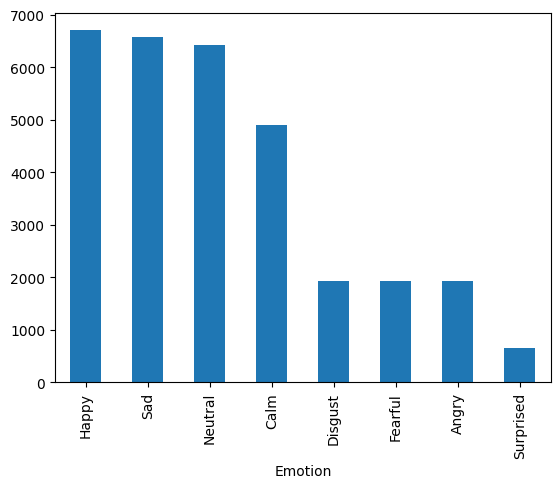

In [17]:
audios.Emotion.value_counts().plot.bar()

In [18]:
# Saving the audio files dataset
audios.to_csv("audio_files.csv", index=False)

In [19]:
import os
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Wav2Vec2Processor, 
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2Config,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset as HFDataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All packages imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

2025-07-02 23:06:42.293924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751497602.495726      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751497602.554453      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ All packages imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True


📊 Loading and exploring dataset...
✅ Loaded dataset from /kaggle/working/audio_files.csv

📈 Dataset Shape: (31022, 3)
Columns: ['Dataset', 'Path', 'Emotion']

🎭 Emotion Distribution:
Emotion
Happy        6703
Sad          6571
Neutral      6425
Calm         4902
Disgust      1923
Fearful      1923
Angry        1923
Surprised     652
Name: count, dtype: int64


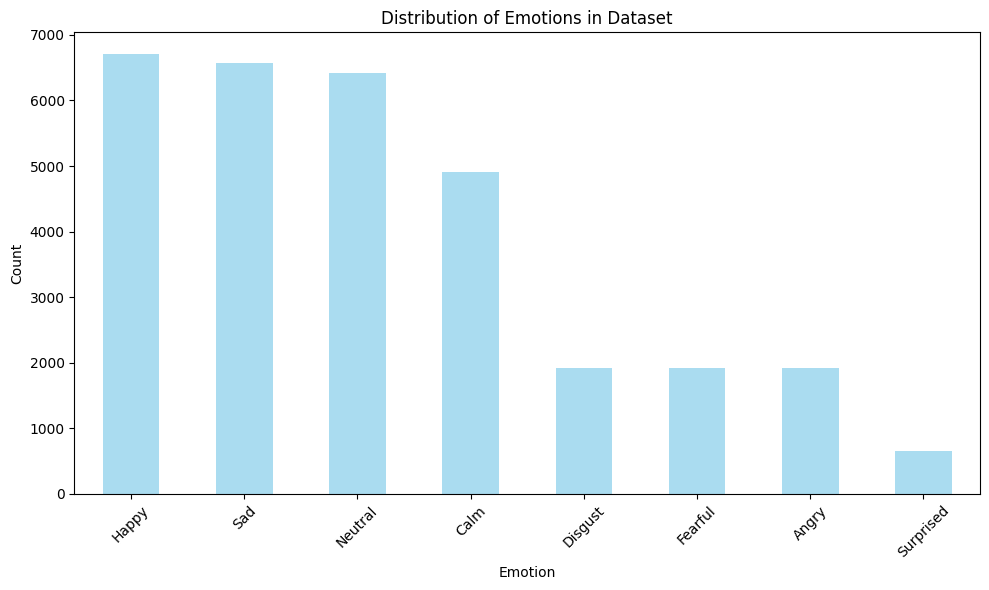


📁 Dataset Source Distribution:
Dataset
MLEnd      18860
CREMA-D     7442
TESS        2800
RAVDESS     1440
SAVEE        480
Name: count, dtype: int64


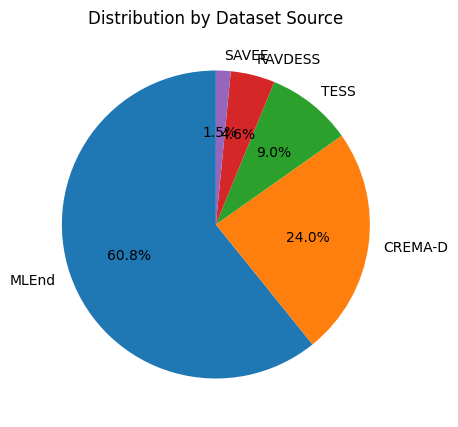

In [20]:
def load_and_explore_dataset(csv_path='/kaggle/working/audio_files.csv', dataframe=None):
    """
    Load dataset and perform initial exploration
    """
    print("📊 Loading and exploring dataset...")
    
    if dataframe is not None:
        df = dataframe.copy()
        print("✅ Using provided DataFrame")
    elif csv_path is not None:
        df = pd.read_csv(csv_path)
        print(f"✅ Loaded dataset from {csv_path}")
    else:
        print("No data source found!")
        return

    # Basic info
    print(f"\n📈 Dataset Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Check for required columns
    required_columns = ['Path', 'Emotion']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"❌ Missing required columns: {missing_columns}")
    
    # Remove rows with missing values
    initial_len = len(df)
    df = df.dropna(subset=required_columns)
    if len(df) < initial_len:
        print(f"⚠️  Removed {initial_len - len(df)} rows with missing values")
    
    # Emotion distribution
    print(f"\n🎭 Emotion Distribution:")
    emotion_counts = df['Emotion'].value_counts()
    print(emotion_counts)
    
    # Plot emotion distribution
    plt.figure(figsize=(10, 6))
    emotion_counts.plot(kind='bar', color='skyblue', alpha=0.7)
    plt.title('Distribution of Emotions in Dataset')
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    # Dataset source distribution (if available)
    if 'Dataset' in df.columns:
        print(f"\n📁 Dataset Source Distribution:")
        dataset_counts = df['Dataset'].value_counts()
        print(dataset_counts)
        
        plt.figure(figsize=(8, 5))
        dataset_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
        plt.title('Distribution by Dataset Source')
        plt.ylabel('')
        plt.show()
    
    return df

df = load_and_explore_dataset()

In [21]:
class AudioEmotionDataset(Dataset):
    """Custom dataset for audio emotion classification with progress tracking"""
    
    def __init__(self, dataframe, processor, target_sampling_rate=16000, max_length_seconds=10):
        self.data = dataframe.reset_index(drop=True)
        self.processor = processor
        self.target_sampling_rate = target_sampling_rate
        self.max_length = target_sampling_rate * max_length_seconds
        
        # Create label encoder
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(dataframe['Emotion'])
        self.num_labels = len(self.label_encoder.classes_)
        
        print(f"📚 Dataset initialized with {len(self.data)} samples")
        print(f"🏷️  Labels: {list(self.label_encoder.classes_)}")
        print(f"🎯 Number of classes: {self.num_labels}")
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get audio file path and emotion
        audio_path = self.data.iloc[idx]['Path']
        emotion = self.data.iloc[idx]['Emotion']
        
        try:
            # Load audio file
            audio_array, sample_rate = librosa.load(audio_path, sr=None)
            
            # Resample to target sampling rate if needed
            if sample_rate != self.target_sampling_rate:
                audio_array = librosa.resample(
                    audio_array, 
                    orig_sr=sample_rate, 
                    target_sr=self.target_sampling_rate
                )
            
            # Ensure audio is not too long (truncate if necessary)
            if len(audio_array) > self.max_length:
                audio_array = audio_array[:self.max_length]
            
            # Process audio with Wav2Vec2 processor
            inputs = self.processor(
                audio_array,
                sampling_rate=self.target_sampling_rate,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=self.max_length
            )
            
            return {
                'input_values': inputs.input_values.squeeze(),
                'attention_mask': inputs.attention_mask.squeeze() if 'attention_mask' in inputs else None,
                'labels': torch.tensor(self.labels[idx], dtype=torch.long)
            }
            
        except Exception as e:
            print(f"⚠️  Error loading audio file {audio_path}: {str(e)}")
            # Return zeros in case of error
            return {
                'input_values': torch.zeros(self.max_length),
                'attention_mask': torch.ones(self.max_length),
                'labels': torch.tensor(0, dtype=torch.long)
            }

✂️  Splitting dataset...
📊 Dataset Split Summary:
   Training:   21714 samples (70.0%)
   Validation: 3103 samples (10.0%)
   Test:       6205 samples (20.0%)


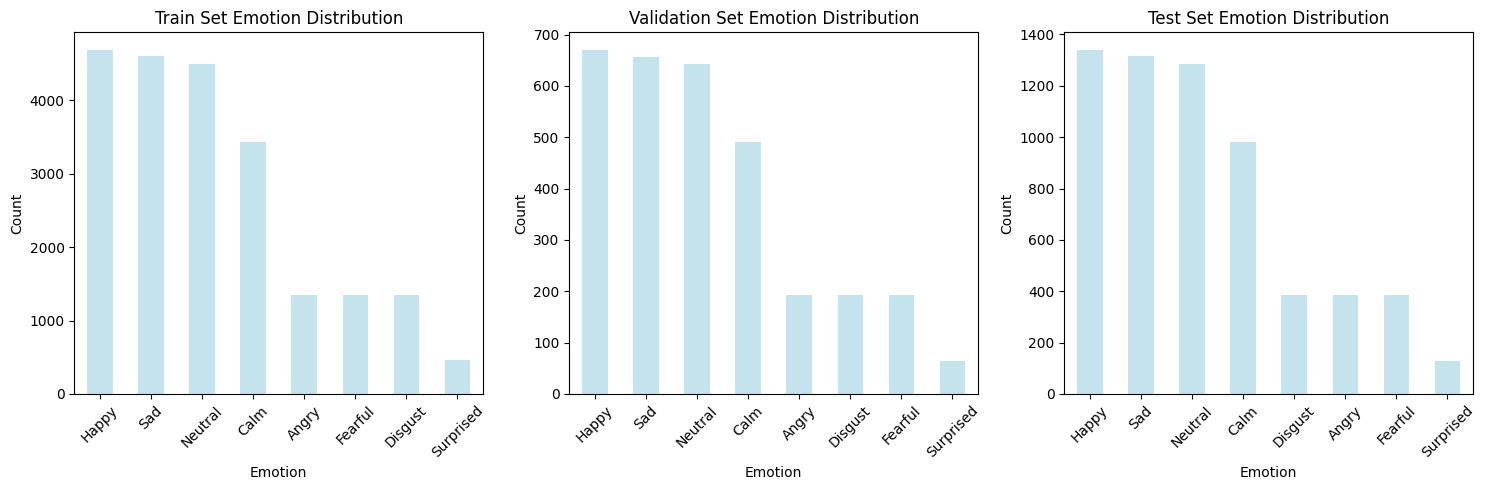

In [22]:
def split_dataset(df, test_size=0.2, val_size=0.1, random_state=42):
    """
    Split dataset into train, validation, and test sets with progress tracking
    """
    print("✂️  Splitting dataset...")
    
    # First split: train + val, test
    train_val_df, test_df = train_test_split(
        df, 
        test_size=test_size, 
        stratify=df['Emotion'], 
        random_state=random_state
    )
    
    # Second split: train, val
    val_size_adjusted = val_size / (1 - test_size)
    train_df, val_df = train_test_split(
        train_val_df, 
        test_size=val_size_adjusted, 
        stratify=train_val_df['Emotion'], 
        random_state=random_state
    )
    
    print(f"📊 Dataset Split Summary:")
    print(f"   Training:   {len(train_df):4d} samples ({len(train_df)/len(df)*100:.1f}%)")
    print(f"   Validation: {len(val_df):4d} samples ({len(val_df)/len(df)*100:.1f}%)")
    print(f"   Test:       {len(test_df):4d} samples ({len(test_df)/len(df)*100:.1f}%)")
    
    # Show emotion distribution in each split
    splits = {'Train': train_df, 'Validation': val_df, 'Test': test_df}
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for idx, (split_name, split_df) in enumerate(splits.items()):
        emotion_counts = split_df['Emotion'].value_counts()
        emotion_counts.plot(kind='bar', ax=axes[idx], color='lightblue', alpha=0.7)
        axes[idx].set_title(f'{split_name} Set Emotion Distribution')
        axes[idx].set_xlabel('Emotion')
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    return train_df, val_df, test_df

# Split the dataset
train_df, val_df, test_df = split_dataset(df)

In [23]:
def setup_model_and_processor(model_name="facebook/wav2vec2-base", num_labels=None):
    """
    Setup Wav2Vec2 model and processor
    """
    print(f"🤖 Setting up model: {model_name}")
    
    # Load processor
    print("   Loading processor...")
    processor = Wav2Vec2Processor.from_pretrained(model_name)
    
    # Load model configuration
    print("   Configuring model...")
    config = Wav2Vec2Config.from_pretrained(model_name)
    if num_labels:
        config.num_labels = num_labels
    config.classifier_dropout = 0.1
    
    # Load model for sequence classification
    print("   Loading model...")
    model = Wav2Vec2ForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )
    
    # Freeze feature extractor (optional - you can unfreeze for full fine-tuning)
    model.freeze_feature_extractor()
    print("   ❄️  Feature extractor frozen")
    
    # Model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"   📊 Model Parameters:")
    print(f"      Total:     {total_params:,}")
    print(f"      Trainable: {trainable_params:,}")
    print(f"      Frozen:    {total_params - trainable_params:,}")
    
    return model, processor

# Initialize processor first
model, processor = setup_model_and_processor(num_labels=len(df['Emotion'].unique()))

🤖 Setting up model: facebook/wav2vec2-base
   Loading processor...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

   Configuring model...
   Loading model...


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ❄️  Feature extractor frozen
   📊 Model Parameters:
      Total:     94,570,632
      Trainable: 90,370,184
      Frozen:    4,200,448


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [24]:
def create_datasets(train_df, val_df, test_df, processor):
    """
    Create dataset objects with progress tracking
    """
    print("🏗️  Creating dataset objects...")
    
    datasets = {}
    
    with tqdm(total=3, desc="Creating datasets") as pbar:
        # Training dataset
        pbar.set_description("Creating training dataset")
        train_dataset = AudioEmotionDataset(train_df, processor)
        datasets['train'] = train_dataset
        pbar.update(1)
        
        # Validation dataset  
        pbar.set_description("Creating validation dataset")
        val_dataset = AudioEmotionDataset(val_df, processor)
        datasets['val'] = val_dataset
        pbar.update(1)
        
        # Test dataset
        pbar.set_description("Creating test dataset")
        test_dataset = AudioEmotionDataset(test_df, processor)
        datasets['test'] = test_dataset
        pbar.update(1)
    
    print("✅ All datasets created successfully!")
    
    return datasets

def collate_fn(batch):
    """Custom collate function for DataLoader with progress-friendly batching"""
    input_values = []
    attention_masks = []
    labels = []
    
    # Find max length in batch for padding
    max_length = max([item['input_values'].shape[0] for item in batch])
    
    for item in batch:
        input_val = item['input_values']
        
        # Pad input values
        if input_val.shape[0] < max_length:
            padding = torch.zeros(max_length - input_val.shape[0])
            input_val = torch.cat([input_val, padding])
        
        input_values.append(input_val)
        
        # Create attention mask
        attention_mask = torch.ones(len(input_val))
        if input_val.shape[0] < max_length:
            mask_padding = torch.zeros(max_length - input_val.shape[0])
            attention_mask = torch.cat([attention_mask, mask_padding])
        attention_masks.append(attention_mask)
        
        labels.append(item['labels'])
    
    return {
        'input_values': torch.stack(input_values),
        'attention_mask': torch.stack(attention_masks),
        'labels': torch.stack(labels)
    }

# Create datasets
datasets = create_datasets(train_df, val_df, test_df, processor)
train_dataset = datasets['train']
val_dataset = datasets['val']
test_dataset = datasets['test']

🏗️  Creating dataset objects...


Creating datasets:   0%|          | 0/3 [00:00<?, ?it/s]

📚 Dataset initialized with 21714 samples
🏷️  Labels: ['Angry', 'Calm', 'Disgust', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']
🎯 Number of classes: 8
📚 Dataset initialized with 3103 samples
🏷️  Labels: ['Angry', 'Calm', 'Disgust', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']
🎯 Number of classes: 8
📚 Dataset initialized with 6205 samples
🏷️  Labels: ['Angry', 'Calm', 'Disgust', 'Fearful', 'Happy', 'Neutral', 'Sad', 'Surprised']
🎯 Number of classes: 8
✅ All datasets created successfully!


In [27]:
!pip install wandb
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

my_secret = user_secrets.get_secret("speech-recognition") 

wandb.login(key=my_secret)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: shajeer4382 (shajeer4382-institute-of-space-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [28]:
def create_compute_metrics_fn(label_encoder):
    """Create compute metrics function for evaluation"""
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        
        accuracy = accuracy_score(labels, predictions)
        
        # Get class names for better reporting
        class_names = label_encoder.classes_
        report = classification_report(
            labels, predictions, 
            target_names=class_names, 
            output_dict=True, 
            zero_division=0
        )
        
        return {
            'accuracy': accuracy,
            'f1_macro': report['macro avg']['f1-score'],
            'f1_weighted': report['weighted avg']['f1-score']
        }
    
    return compute_metrics

def setup_training_args(output_dir="./wav2vec2-emotion-model", epochs=10, batch_size=32):
    """
    Setup training arguments with sensible defaults
    """
    print("⚙️  Setting up training arguments...")
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        warmup_steps=100,
        logging_steps=20,  # More frequent logging for progress tracking
        eval_strategy="steps",
        eval_steps=50,
        save_steps=100,
        save_total_limit=3,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        push_to_hub=False,
        dataloader_num_workers=2,  # Reduced for stability
        learning_rate=1e-4,
        weight_decay=0.01,
        adam_epsilon=1e-8,
        max_grad_norm=1.0,
        lr_scheduler_type="linear",
        report_to=None,  # Disable wandb/tensorboard logging
        disable_tqdm=False,  # Enable tqdm progress bars
        fp16=True,
        gradient_accumulation_steps=5,
        gradient_checkpointing=True
    )
    
    print(f"   📁 Output directory: {output_dir}")
    print(f"   🔄 Epochs: {epochs}")
    print(f"   📦 Batch size: {batch_size}")
    print(f"   📈 Learning rate: {training_args.learning_rate}")
    
    return training_args


In [29]:
def train_model(model, train_dataset, val_dataset, output_dir="./wav2vec2-emotion-model"):
    """
    Train the model with progress tracking
    """
    print("🚀 Starting model training...")
    
    # Setup training arguments
    training_args = setup_training_args(output_dir=output_dir)
    
    # Create compute metrics function
    compute_metrics = create_compute_metrics_fn(train_dataset.label_encoder)
    
    # Initialize trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=collate_fn,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
    )
    
    # Train model
    print("⏳ Training in progress...")
    train_result = trainer.train()
    
    # Save model and processor
    print("💾 Saving model...")
    trainer.save_model(output_dir)
    processor.save_pretrained(output_dir)
    
    # Save label encoder
    import joblib
    joblib.dump(train_dataset.label_encoder, os.path.join(output_dir, 'label_encoder.pkl'))
    
    print("✅ Training completed successfully!")
    print(f"📊 Training Results:")
    print(f"   Final Loss: {train_result.training_loss:.4f}")
    print(f"   Training Steps: {train_result.global_step}")
    
    return trainer, train_result

# Start training
trainer, train_result = train_model(model, train_dataset, val_dataset)

🚀 Starting model training...
⚙️  Setting up training arguments...
   📁 Output directory: ./wav2vec2-emotion-model
   🔄 Epochs: 10
   📦 Batch size: 32
   📈 Learning rate: 0.0001


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


⏳ Training in progress...


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
50,1.841100,1.618820,0.409604,0.257891,0.360131
100,1.144300,1.043358,0.639704,0.487726,0.623832
150,0.905400,0.742843,0.754431,0.726307,0.747308
200,0.681700,0.610536,0.792781,0.783768,0.791091
250,0.566300,0.556033,0.806316,0.803493,0.812795
300,0.438300,0.513013,0.831131,0.814898,0.832206
350,0.392600,0.458236,0.851434,0.844603,0.851374
400,0.399000,0.423015,0.858202,0.850533,0.858107
450,0.319700,0.432259,0.861424,0.857878,0.861137
500,0.269900,0.388723,0.871092,0.862746,0.871440


💾 Saving model...
✅ Training completed successfully!
📊 Training Results:
   Final Loss: 0.3528
   Training Steps: 1350


📊 Evaluating model performance...


🎯 Test Results:
   Loss: 0.4212
   Accuracy: 0.8967
   F1_Macro: 0.8834
   F1_Weighted: 0.8970
   Runtime: 58.5264
   Samples_Per_Second: 106.0210
   Steps_Per_Second: 3.3150
🔍 Generating detailed predictions...

📋 Detailed Classification Report:
              precision    recall  f1-score   support

       Angry       0.89      0.92      0.91       385
        Calm       0.97      0.94      0.96       980
     Disgust       0.84      0.81      0.82       385
     Fearful       0.75      0.76      0.75       385
       Happy       0.94      0.90      0.92      1341
     Neutral       0.88      0.92      0.90      1285
         Sad       0.88      0.89      0.88      1314
   Surprised       0.90      0.95      0.92       130

    accuracy                           0.90      6205
   macro avg       0.88      0.89      0.88      6205
weighted avg       0.90      0.90      0.90      6205



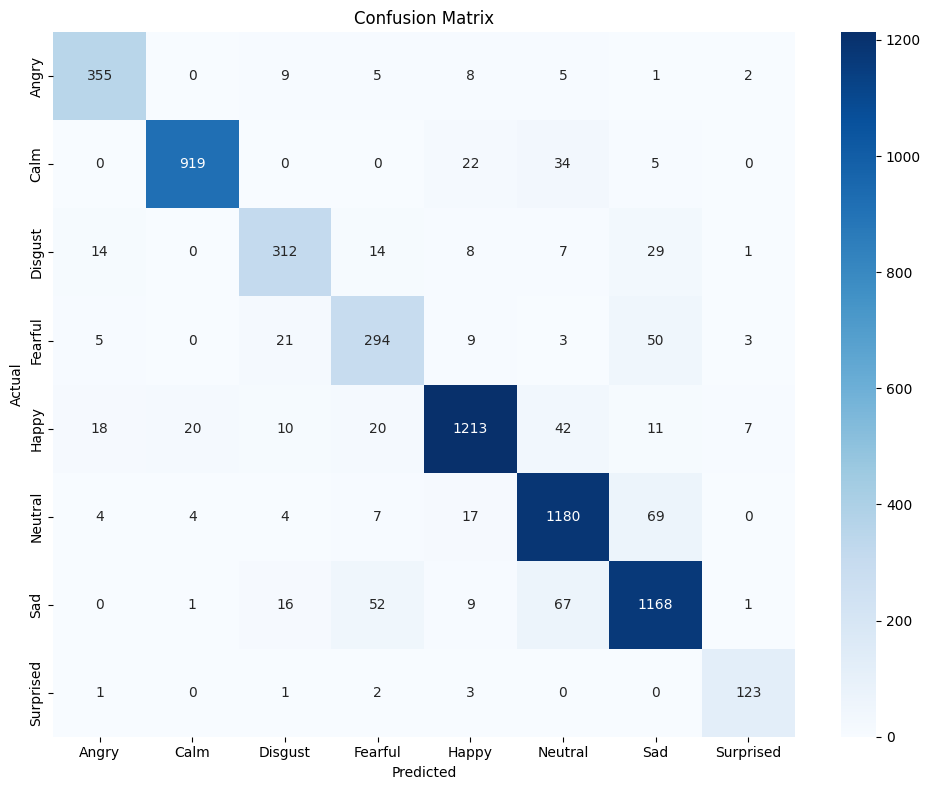

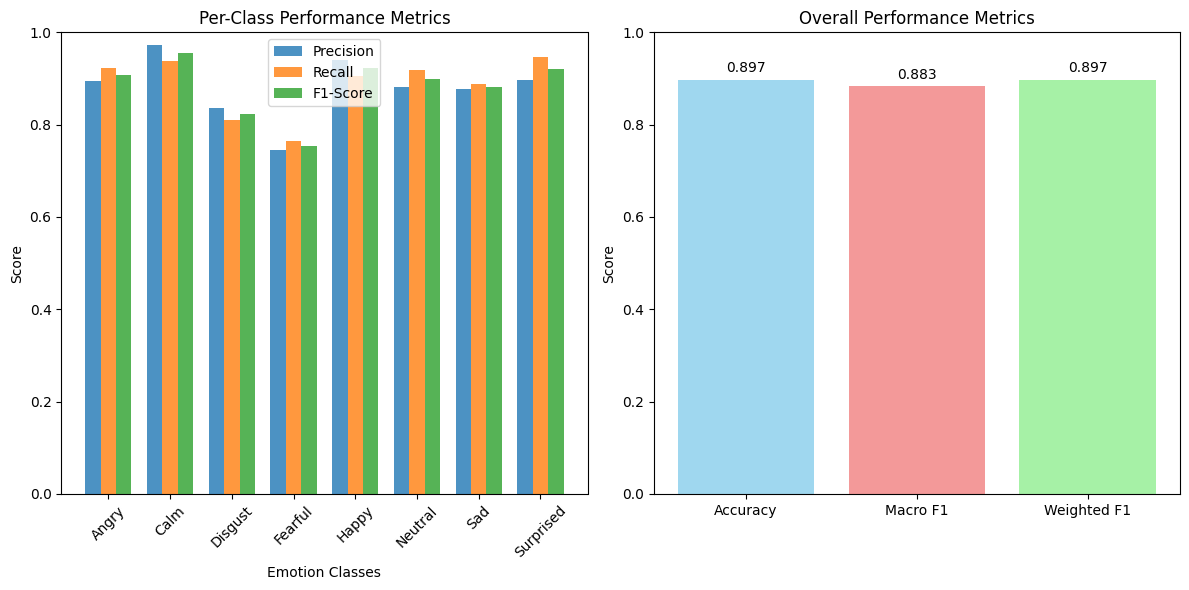

In [30]:
def evaluate_model(trainer, test_dataset, label_encoder):
    """
    Comprehensive model evaluation with visualizations
    """
    print("📊 Evaluating model performance...")
    
    # Evaluate on test set
    test_results = trainer.evaluate(test_dataset)
    
    print(f"🎯 Test Results:")
    for key, value in test_results.items():
        if key.startswith('eval_'):
            metric_name = key.replace('eval_', '').title()
            print(f"   {metric_name}: {value:.4f}")
    
    # Get predictions for detailed analysis
    print("🔍 Generating detailed predictions...")
    predictions = trainer.predict(test_dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids
    
    # Classification report
    class_names = label_encoder.classes_
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    
    print(f"\n📋 Detailed Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    
    # Per-class performance
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    precision_scores = [report[label]['precision'] for label in class_names]
    recall_scores = [report[label]['recall'] for label in class_names]
    f1_scores = [report[label]['f1-score'] for label in class_names]
    
    x = np.arange(len(class_names))
    width = 0.25
    
    plt.bar(x - width, precision_scores, width, label='Precision', alpha=0.8)
    plt.bar(x, recall_scores, width, label='Recall', alpha=0.8)
    plt.bar(x + width, f1_scores, width, label='F1-Score', alpha=0.8)
    
    plt.xlabel('Emotion Classes')
    plt.ylabel('Score')
    plt.title('Per-Class Performance Metrics')
    plt.xticks(x, class_names, rotation=45)
    plt.legend()
    plt.ylim(0, 1)
    
    # Overall metrics comparison
    plt.subplot(1, 2, 2)
    overall_metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
    overall_scores = [
        test_results['eval_accuracy'],
        test_results['eval_f1_macro'],
        test_results['eval_f1_weighted']
    ]
    
    bars = plt.bar(overall_metrics, overall_scores, color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8)
    plt.ylabel('Score')
    plt.title('Overall Performance Metrics')
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for bar, score in zip(bars, overall_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{score:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return test_results, y_pred, y_true

# Evaluate the model
test_results, predictions, true_labels = evaluate_model(trainer, test_dataset, train_dataset.label_encoder)

In [31]:
def predict_single_audio(audio_path, model_path="/kaggle/working/wav2vec2-emotion-model"):
    """
    Predict emotion for a single audio file
    """
    import joblib
    
    print(f"🎵 Predicting emotion for: {audio_path}")
    
    # Load model and processor
    model = Wav2Vec2ForSequenceClassification.from_pretrained(model_path)
    processor = Wav2Vec2Processor.from_pretrained(model_path)
    label_encoder = joblib.load(os.path.join(model_path, 'label_encoder.pkl'))
    
    try:
        # Load and preprocess audio
        audio_array, sample_rate = librosa.load(audio_path, sr=16000)
        
        # Process audio
        inputs = processor(
            audio_array,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
            truncation=False
        )
        
        # Make prediction
        with torch.no_grad():
            logits = model(**inputs).logits
            probabilities = torch.softmax(logits, dim=-1)
            predicted_class_id = logits.argmax().item()
            predicted_emotion = label_encoder.inverse_transform([predicted_class_id])[0]
            confidence = probabilities.max().item()
        
        # Get all class probabilities
        all_probs = probabilities.squeeze().numpy()
        emotion_probs = {
            emotion: prob for emotion, prob in zip(label_encoder.classes_, all_probs)
        }
        
        print(f"   🎯 Predicted: {predicted_emotion}")
        print(f"   📊 Confidence: {confidence:.4f}")
        print(f"   📈 All probabilities:")
        for emotion, prob in sorted(emotion_probs.items(), key=lambda x: x[1], reverse=True):
            print(f"      {emotion}: {prob:.4f}")
        
        return predicted_emotion, confidence, emotion_probs
        
    except Exception as e:
        print(f"❌ Error processing audio: {str(e)}")
        return None, 0.0, {}

def batch_predict_with_progress(audio_paths, model_path="./wav2vec2-emotion-model"):
    """
    Predict emotions for multiple audio files with progress tracking
    """
    print(f"🔄 Processing {len(audio_paths)} audio files...")
    
    predictions = []
    
    for audio_path in tqdm(audio_paths, desc="Predicting emotions"):
        try:
            emotion, confidence, probs = predict_single_audio(audio_path, model_path)
            predictions.append({
                'audio_path': audio_path,
                'predicted_emotion': emotion,
                'confidence': confidence,
                **{f'prob_{emotion}': prob for emotion, prob in probs.items()}
            })
        except Exception as e:
            print(f"⚠️  Error processing {audio_path}: {str(e)}")
            predictions.append({
                'audio_path': audio_path,
                'predicted_emotion': 'Error',
                'confidence': 0.0
            })
    
    results_df = pd.DataFrame(predictions)
    print("✅ Batch prediction completed!")
    
    return results_df

Example usage (uncomment and modify paths as needed)
single_prediction = predict_single_audio("/path/to/your/audio.wav")

In [32]:
single_prediction = predict_single_audio("/kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_a05.wav")

🎵 Predicting emotion for: /kaggle/input/surrey-audiovisual-expressed-emotion-savee/ALL/DC_a05.wav
   🎯 Predicted: Angry
   📊 Confidence: 0.9106
   📈 All probabilities:
      Angry: 0.9106
      Disgust: 0.0723
      Fearful: 0.0135
      Surprised: 0.0024
      Neutral: 0.0007
      Happy: 0.0003
      Sad: 0.0001
      Calm: 0.0001


In [33]:
single_prediction = predict_single_audio("/kaggle/input/mlend-spoken-numerals/MLEndSND_Public/MLEndSND_Public/00042.wav")

🎵 Predicting emotion for: /kaggle/input/mlend-spoken-numerals/MLEndSND_Public/MLEndSND_Public/00042.wav
   🎯 Predicted: Calm
   📊 Confidence: 0.9978
   📈 All probabilities:
      Calm: 0.9978
      Surprised: 0.0009
      Neutral: 0.0005
      Happy: 0.0004
      Sad: 0.0001
      Angry: 0.0001
      Disgust: 0.0001
      Fearful: 0.0000
